### Imports and Configuration


In [1]:
# Import shared libraries, metrics, and utilities used across the full RT-IoT2022 modeling workflow.
# Keep metric imports centralized so split evaluation and cross-validation use consistent definitions.
# Configure warnings once to keep lengthy experiment logs readable during repeated notebook runs.

import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score,
                              average_precision_score)
from sklearn.model_selection import StratifiedKFold, cross_validate

### Paths and Data Loading


In [2]:
# Build project-relative paths to keep the notebook portable across machines and environments.
# Load prepared RT-IoT2022 train/validation/test splits so each algorithm is tested on identical partitions.
# Ensure output directories exist before fitting so artifact persistence does not fail at completion.

from pathlib import Path
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

NOTEBOOK_DIR =  Path('/content/drive/MyDrive/MLmodeling/XAI/notebooks_v1')
BASE_DIR     = Path('/content/drive/MyDrive/MLmodeling/XAI')
DATASET_DIR  = BASE_DIR / 'Datasets' / 'RT-IoT2022'
SPLITS_DIR   = BASE_DIR / 'splits' / 'RT-IoT2022'
MODEL_DIR    = BASE_DIR / 'models' / 'RT-IoT2022'
RESULT_DIR   = BASE_DIR / 'results' / 'RT-IoT2022'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(SPLITS_DIR / 'X_train.csv').values
X_val   = pd.read_csv(SPLITS_DIR / 'X_val.csv').values
X_test  = pd.read_csv(SPLITS_DIR / 'X_test.csv').values

y_train = pd.read_csv(SPLITS_DIR / 'y_train.csv').squeeze()
y_val   = pd.read_csv(SPLITS_DIR / 'y_val.csv').squeeze()
y_test  = pd.read_csv(SPLITS_DIR / 'y_test.csv').squeeze()

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Mounted at /content/drive
Train: (86181, 93) | Val: (18468, 93) | Test: (18468, 93)


### Model Definition


In [3]:
# Define IsolationForest with explicit hyperparameters so this run stays reproducible and easy to compare.
# Keep model initialization separate from training/evaluation so tuning edits remain localized.
# `random_state=42` reduces run-to-run variation and keeps benchmark comparisons fair.

from sklearn.ensemble import IsolationForest

ARTIFACT_NAME = "RT_15_IsolationForest"
MODEL_NAME = "IsolationForest"
model = IsolationForest(contamination='auto', random_state=42, n_jobs=-1)


### Train and Evaluate


In [4]:
# Fit the model and evaluate train/validation/test in one pass to expose overfitting or underfitting quickly.
# Report threshold metrics (accuracy, precision, recall, F1, F2) and ranking metrics (ROC-AUC, PR-AUC).
# PR-AUC is particularly informative for imbalanced attack detection, so it complements ROC-AUC here.

# Unsupervised   fit on train features only, no labels
model.fit(X_train)

def predict_binary(model, X):
    # -1 = anomaly = attack (1), +1 = inlier = normal (0)
    return np.where(model.predict(X) == -1, 1, 0)

y_pred_train = predict_binary(model, X_train)
y_pred_val   = predict_binary(model, X_val)
y_pred_test  = predict_binary(model, X_test)

def eval_unsupervised(y_true, y_pred, split_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    f2   = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    print(f"{split_name:6s}   Accuracy: {acc:.4f} | Precision: {prec:.4f} | "
          f"Recall: {rec:.4f} | F1: {f1:.4f} | F2: {f2:.4f}")

eval_unsupervised(y_train, y_pred_train, "Train")
eval_unsupervised(y_val,   y_pred_val,   "Val")
eval_unsupervised(y_test,  y_pred_test,  "Test")

Train    Accuracy: 0.0775 | Precision: 0.4000 | Recall: 0.0537 | F1: 0.0947 | F2: 0.0650
Val      Accuracy: 0.0793 | Precision: 0.4083 | Recall: 0.0551 | F1: 0.0972 | F2: 0.0667
Test     Accuracy: 0.0776 | Precision: 0.4035 | Recall: 0.0557 | F1: 0.0979 | F2: 0.0673


### Model Evaluation (Unsupervised - No cross validation)

In [5]:
# Isolation Forest is an unsupervised learning model.
# It does not use labeled data (y), so techniques like Stratified K-Fold CV
# cannot be applied because they rely on class labels to split data.

# In unsupervised learning:
# - There is no ground truth for validation during training
# - Metrics like F1, ROC require true labels, which are not available
# - Hence, traditional cross-validation is not applicable

# Instead, we evaluate stability using:
# - Train / Validation / Test consistency
# - Distribution of anomaly scores
# - Domain-based validation (if labels available externally)

cv_results = {
    "cv_train_f1_mean": None,
    "cv_val_f1_mean":   None,
    "cv_val_f1_std":    None,
    "cv_val_roc_mean":  None,
    "cv_val_pr_mean":   None,
    "cv_gap":           None,
}
train_test_gap = None
print("CV skipped   unsupervised model")

CV skipped   unsupervised model


### Save Results and Model Artifact


In [6]:
# Assemble a standardized result row so this notebook remains compatible with the shared benchmark schema.
# Save this notebook's latest metrics snapshot to CSV (default `to_csv` overwrites on rerun).
# Persist the trained model artifact for downstream interpretability workflows such as SHAP and LIME.

row = {
    "dataset":         "RT-IoT2022",
    "model":           MODEL_NAME,
    "split":           "70/15/15",
    "test_accuracy":   round(accuracy_score(y_test, y_pred_test), 6),
    "test_precision":  round(precision_score(y_test, y_pred_test, zero_division=0), 6),
    "test_recall":     round(recall_score(y_test, y_pred_test, zero_division=0), 6),
    "test_f1":         round(f1_score(y_test, y_pred_test, zero_division=0), 6),
    "test_f2":         round(fbeta_score(y_test, y_pred_test, beta=2, zero_division=0), 6),
    "test_roc_auc":    None,
    "test_pr_auc":     None,
    "val_f1":          round(f1_score(y_val, y_pred_val, zero_division=0), 6),
    "val_f2":          round(fbeta_score(y_val, y_pred_val, beta=2, zero_division=0), 6),
    "val_roc_auc":     None,
    "val_pr_auc":      None,
    "train_f1":        round(f1_score(y_train, y_pred_train, zero_division=0), 6),
    "cv_val_f1_mean":  None,
    "cv_val_f1_std":   None,
    "cv_val_roc_mean": None,
    "cv_val_pr_mean":  None,
    "cv_gap":          None,
    "train_test_gap":  None,
}

pd.DataFrame([row]).to_csv(f"{RESULT_DIR}//{ARTIFACT_NAME}.csv", index=False)
joblib.dump(model, f"{MODEL_DIR}//{ARTIFACT_NAME}.pkl")
print(f"{ARTIFACT_NAME}   saved.")
print(pd.DataFrame([row]).T.to_string(header=False))

RT_15_IsolationForest   saved.
dataset               RT-IoT2022
model            IsolationForest
split                   70/15/15
test_accuracy           0.077648
test_precision          0.403493
test_recall             0.055689
test_f1                 0.097871
test_f2                  0.06729
test_roc_auc                None
test_pr_auc                 None
val_f1                   0.09717
val_f2                  0.066682
val_roc_auc                 None
val_pr_auc                  None
train_f1                0.094733
cv_val_f1_mean              None
cv_val_f1_std               None
cv_val_roc_mean             None
cv_val_pr_mean              None
cv_gap                      None
train_test_gap              None


In [7]:
# Widget inference setup: load model + feature defaults + optional preprocessing artifacts.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Resolve project root robustly so this cell can run standalone.
# Previous code for BASE_DIR resolution was removed to align with earlier explicitly defined BASE_DIR.
BASE_DIR = Path('/content/drive/MyDrive/MLmodeling/XAI')

FEATURES_FILE = BASE_DIR / 'features' / 'RT-IoT2022_features.json'
MODEL_FILE = BASE_DIR / 'models' / 'RT-IoT2022' / 'RT_15_IsolationForest.pkl'
SPLIT_DIR = BASE_DIR / 'splits' / 'RT-IoT2022'

assert FEATURES_FILE.exists(), f'Feature defaults not found: {FEATURES_FILE}'
assert MODEL_FILE.exists(), f'Model file not found: {MODEL_FILE}'

with open(FEATURES_FILE, 'r', encoding='utf-8') as f:
    RT_DEFAULTS = json.load(f)

# Set CAT_OPTIONS to an empty dictionary as per user request to skip categorical features.
CAT_OPTIONS = {}

# Exclude non-predictive raw columns if they still exist in feature JSON.
EXCLUDE_COLS = {'no', 'Attack_type'}
RT_DEFAULTS = {k: v for k, v in RT_DEFAULTS.items() if k not in EXCLUDE_COLS}

INFER_MODEL = joblib.load(MODEL_FILE)

INFER_PREPROCESSOR = None
for pp_name in ('preprocessor.joblib', 'preprocessor.pkl'):
    pp_path = SPLIT_DIR / pp_name
    if pp_path.exists():
        INFER_PREPROCESSOR = joblib.load(pp_path)
        break

INFER_FEATURE_NAMES = None
fn_path = SPLIT_DIR / 'feature_names.csv'
if fn_path.exists():
    INFER_FEATURE_NAMES = pd.read_csv(fn_path, header=None).squeeze().tolist()

print(f'Loaded model: {MODEL_FILE.name}')
print(f'Feature defaults: {len(RT_DEFAULTS)}')
print(f'Preprocessor loaded: {INFER_PREPROCESSOR is not None}')


Loaded model: RT_15_IsolationForest.pkl
Feature defaults: 83
Preprocessor loaded: True


In [8]:
if 'RT_DEFAULTS' not in globals():
    print('Run the previous widget setup cell first.')
else:
    input_widgets = {}

    # Removed the hardcoded CAT_OPTIONS as per user request to skip categorical features.
    # The widget will now only use numerical inputs based on RT_DEFAULTS.

    def make_widget(col, default):
        # Now assuming all inputs should be numerical based on user request.
        # Handle int and float specifically, otherwise default to float.
        if isinstance(default, int) and not isinstance(default, bool):
            return widgets.IntText(value=int(default), layout=widgets.Layout(width='360px', min_width='300px', height='34px'))
        # All other cases, including floats and any string defaults (which will be attempted to convert to float)
        # This will raise a ValueError if a string cannot be converted to float, but per user request, we are skipping
        # explicit categorical handling, implying these should be numerical for the model.
        return widgets.FloatText(value=float(default), step=0.01, layout=widgets.Layout(width='360px', min_width='300px', height='34px'))

    def to_group_name(col_name):
        if '.' in col_name:
            return col_name.split('.', 1)[0]
        if '_' in col_name:
            return col_name.split('_', 1)[0]
        return 'other'

    feature_groups = {}
    for col, default in RT_DEFAULTS.items():
        # Skip string defaults if CAT_OPTIONS is empty, as per the intention to only handle numerical inputs
        if isinstance(default, str) and not CAT_OPTIONS:
            continue
        w = make_widget(col, default)
        input_widgets[col] = w
        group = to_group_name(col)
        feature_groups.setdefault(group, []).append(col)

    sorted_groups = sorted(feature_groups.keys())
    group_boxes = []

    for group in sorted_groups:
        rows = []
        for col in feature_groups[group]:
            label = widgets.HTML(
                value=f'<div style="font-family:monospace; font-size:13px;">{col}</div>',
                layout=widgets.Layout(width='430px', min_width='360px')
            )
            rows.append(
                widgets.HBox(
                    [label, input_widgets[col]],
                    layout=widgets.Layout(justify_content='space-between', width='100%')
                )
            )

        group_box = widgets.VBox(rows, layout=widgets.Layout(gap='8px', padding='8px 4px'))
        group_boxes.append(group_box)

    accordion = widgets.Accordion(
        children=group_boxes,
        layout=widgets.Layout(width='100%', max_height='560px', overflow_y='auto')
    )

    for i, group in enumerate(sorted_groups):
        accordion.set_title(i, f'{group} ({len(feature_groups[group])})')

    if sorted_groups:
        accordion.selected_index = 0

    group_selector = widgets.Dropdown(
        options=[(f'{g} ({len(feature_groups[g])})', i) for i, g in enumerate(sorted_groups)],
        description='Jump to:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='360px')
    )

    search_box = widgets.Text(
        value='',
        placeholder='Type feature name (e.g., proto, flow, dns) then press Enter',
        description='Find:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='620px')
    )

    predict_btn = widgets.Button(
        description='Predict',
        button_style='success',
        icon='check',
        layout=widgets.Layout(width='130px', height='36px')
    )
    reset_btn = widgets.Button(
        description='Reset',
        icon='refresh',
        layout=widgets.Layout(width='110px', height='36px')
    )

    result_out = widgets.Output()

    def on_group_change(change):
        if change['name'] == 'value':
            accordion.selected_index = change['new']

    def on_find_submit(_):
        q = search_box.value.strip().lower()
        if not q:
            return
        for idx, group in enumerate(sorted_groups):
            for col in feature_groups[group]:
                if q in col.lower():
                    accordion.selected_index = idx
                    with result_out:
                        clear_output()
                        print(f'Found in group: {group}. Scroll to locate "{col}".')
                    return
        with result_out:
            clear_output()
            print(f'No feature matched "{q}".')

    group_selector.observe(on_group_change, names='value')
    search_box.on_submit(on_find_submit)

    def _build_input_row():
        row = {}
        # Iterate over all features defined in RT_DEFAULTS
        for c, d in RT_DEFAULTS.items():
            if c in input_widgets: # If a widget was created for this feature
                v = input_widgets[c].value
                # Attempt conversion to int if the default was int, otherwise float.
                if isinstance(d, int) and not isinstance(d, bool):
                    row[c] = int(v)
                else:
                    row[c] = float(v)
            else: # If no widget was created (it was skipped, likely categorical)
                row[c] = d # Use the original default value for this feature
        return row

    def _prepare_X(df_input):
        # Ensure df_input is a DataFrame before manipulation
        if not isinstance(df_input, pd.DataFrame):
            df_input = pd.DataFrame([df_input])

        X_processed_data = None
        if INFER_PREPROCESSOR is not None:
            # Apply preprocessor to the raw input DataFrame (df_input contains raw features)
            X_processed_data = INFER_PREPROCESSOR.transform(df_input)
        else:
            # If no preprocessor, assume the input DataFrame is already in the correct format
            # and numerical. This path is less robust if a preprocessor was expected but not loaded.
            print("Warning: No preprocessor loaded. Assuming raw input is model-ready.")
            X_processed_data = df_input.values # Convert to array for consistency with preprocessor output

        # Ensure the processed data has the correct feature names and order
        if INFER_FEATURE_NAMES is not None:
            # If the preprocessor output is an array, convert to DataFrame with correct names
            if isinstance(X_processed_data, np.ndarray):
                if X_processed_data.shape[1] != len(INFER_FEATURE_NAMES):
                    raise ValueError(f"""Preprocessor output feature count mismatch: expected {len(INFER_FEATURE_NAMES)}, got {X_processed_data.shape[1]}.
This indicates a mismatch between the preprocessor's output and the model's expected features.""")
                X_final = pd.DataFrame(X_processed_data, columns=INFER_FEATURE_NAMES)
            elif isinstance(X_processed_data, pd.DataFrame):
                # If preprocessor returned a DataFrame, reindex it to ensure correct columns and order
                X_final = X_processed_data.reindex(columns=INFER_FEATURE_NAMES, fill_value=0.0)
            else:
                raise TypeError("Unexpected type for X_processed_data after preprocessing.")
        else:
            # If no INFER_FEATURE_NAMES, use the preprocessor output directly (as an array)
            if isinstance(X_processed_data, pd.DataFrame):
                X_final = X_processed_data.values
            else:
                X_final = X_processed_data # Should be numpy array from preprocessor

        # Final check for feature count against the model's expectation
        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None and (isinstance(X_final, pd.DataFrame) and X_final.shape[1] != int(expected_n) or
                                       isinstance(X_final, np.ndarray) and X_final.shape[1] != int(expected_n)):
            raise ValueError(f"""Feature count mismatch for model input: expected {int(expected_n)}, got {X_final.shape[1]}.
This indicates a fundamental mismatch between model and input definitions after all processing.""")

        # Always return a numpy array as expected by most sklearn models
        if isinstance(X_final, pd.DataFrame):
            return X_final.values
        return X_final

    def on_predict(_):
        with result_out:
            clear_output()
            try:
                row = _build_input_row()
                # df_input = pd.DataFrame([row]) # df_input will be handled by _prepare_X
                X_input = _prepare_X(row)

                pred = int(INFER_MODEL.predict(X_input)[0])
                label = 'ATTACK' if pred == 1 else 'NORMAL'
                color = '#d32f2f' if pred == 1 else '#388e3c'

                score_html = ''
                if hasattr(INFER_MODEL, 'predict_proba'):
                    p = INFER_MODEL.predict_proba(X_input)[0]
                    normal_score = float(p[0])
                    attack_score = float(p[1])
                    pred_score = attack_score if pred == 1 else normal_score
                    score_html = (
                        f"<div style='margin-top:8px;font-size:14px;color:#444;'>"
                        f"normal_score={normal_score:.4f} | attack_score={attack_score:.4f} | "
                        f"prediction_confidence={pred_score:.4f}</div>"
                    )
                elif hasattr(INFER_MODEL, 'decision_function'):
                    decision_score = float(np.ravel(INFER_MODEL.decision_function(X_input))[0])
                    score_html = f"<div style='margin-top:8px;font-size:14px;color:#444;'>decision_score={decision_score:.6f}</div>"

                display(HTML(f"""
                    <div style='border:2px solid {color}; border-radius:8px; padding:14px; max-width:700px;'>
                        <div style='font-size:22px; font-weight:700; color:{color};'>Prediction: {label}</div>
                        <div style='margin-top:6px; font-size:13px; color:#666;'>Dataset: RT-IoT | Model: DecisionTree</div>
                        {score_html}
                    </div>
                """))
            except Exception as e:
                print(f'Prediction failed: {e}')

    def on_reset(_):
        for c, d in RT_DEFAULTS.items():
            input_widgets[c].value = d
        with result_out:
            clear_output()
            print('Inputs reset to RT-IoT feature defaults.')

    predict_btn.on_click(on_predict)
    reset_btn.on_click(on_reset)

    controls = widgets.HBox(
        [group_selector, predict_btn, reset_btn],
        layout=widgets.Layout(gap='10px', align_items='center')
    )

    display(widgets.VBox([
        widgets.HTML('<h3 style="margin:0;">RT-IoT Interactive Inference</h3>'),
        widgets.HTML('<div style="color:#555;">Edit values below and click Predict to classify as NORMAL or ATTACK.</div>'),
        search_box,
        controls,
        accordion,
        result_out
    ], layout=widgets.Layout(gap='10px', width='100%')))

## Anomaly Analysis Summary
Rule-of-thumb analysis for anomaly models (without SHAP/LIME):
- Use `decision_function` and `score_samples` for anomaly confidence.
- Lower decision score generally means more anomalous behavior.
- For LOF, neighborhood density differences drive outlier decisions.

Samples evaluated: 5000
Outlier rate: 0.1326


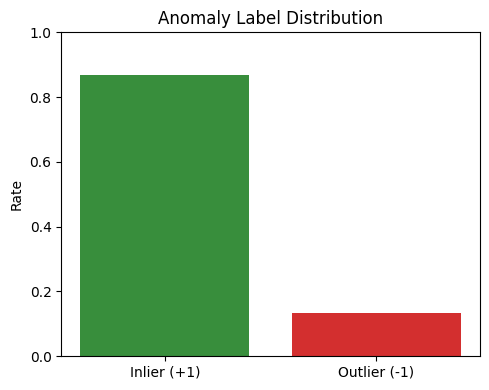

decision_score mean=0.103395, std=0.089358, min=-0.286490, max=0.177422


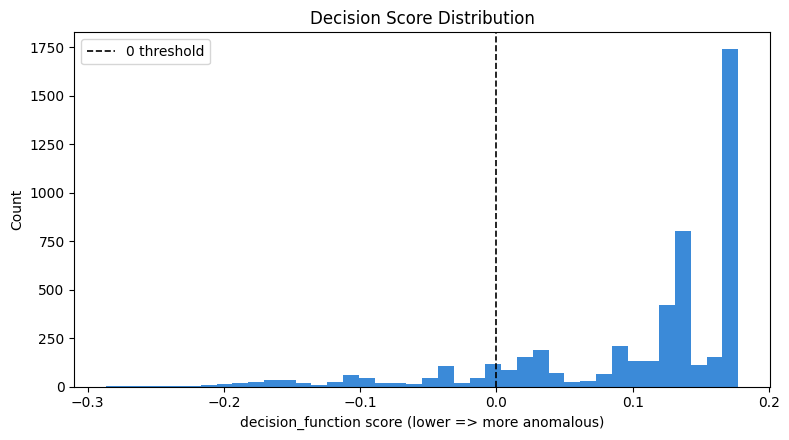

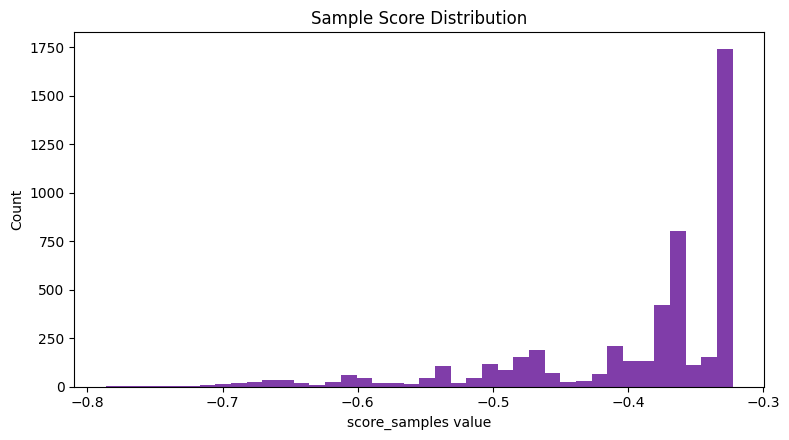

In [9]:
# Diagnostics + diagrams for anomaly score behavior
if 'INFER_MODEL' not in globals():
    print('Run setup cell first.')
else:
    import matplotlib.pyplot as plt

    split_dir = BASE_DIR / 'splits' / 'RT-IoT2022'
    x_test_proc_path = split_dir / 'X_test_proc.npy'
    if x_test_proc_path.exists():
        X_eval = np.load(x_test_proc_path)
    else:
        # X_test (from CSV) is already the preprocessed numerical data used for model training.
        # The INFER_PREPROCESSOR is intended for raw data (e.g., from widget input).
        # Therefore, if x_test_proc.npy doesn't exist, we use X_test directly.
        X_eval = X_test

    if X_eval is None:
        print('No evaluation matrix found for diagnostics.')
    else:
        n = min(5000, X_eval.shape[0])
        X_sub = X_eval[:n]
        preds = INFER_MODEL.predict(X_sub)
        outlier_rate = float((preds == -1).mean())
        inlier_rate = 1.0 - outlier_rate

        print(f'Samples evaluated: {n}')
        print(f'Outlier rate: {outlier_rate:.4f}')

        # Diagram 1: Inlier vs Outlier rate
        plt.figure(figsize=(5, 4))
        plt.bar(['Inlier (+1)', 'Outlier (-1)'], [inlier_rate, outlier_rate], color=['#388e3c', '#d32f2f'])
        plt.ylim(0, 1)
        plt.title('Anomaly Label Distribution')
        plt.ylabel('Rate')
        plt.tight_layout()
        plt.show()

        # Diagram 2: Decision score distribution (when available)
        if hasattr(INFER_MODEL, 'decision_function'):
            d = np.ravel(INFER_MODEL.decision_function(X_sub))
            print(f'decision_score mean={float(d.mean()):.6f}, std={float(d.std()):.6f}, min={float(d.min()):.6f}, max={float(d.max()):.6f}')

            plt.figure(figsize=(8, 4.5))
            plt.hist(d, bins=40, color='#1976d2', alpha=0.85)
            plt.axvline(0.0, color='black', linestyle='--', linewidth=1.2, label='0 threshold')
            plt.title('Decision Score Distribution')
            plt.xlabel('decision_function score (lower => more anomalous)')
            plt.ylabel('Count')
            plt.legend()
            plt.tight_layout()
            plt.show()

        # Diagram 3: score_samples distribution (when available)
        if hasattr(INFER_MODEL, 'score_samples'):
            s = np.ravel(INFER_MODEL.score_samples(X_sub))
            plt.figure(figsize=(8, 4.5))
            plt.hist(s, bins=40, color='#6a1b9a', alpha=0.85)
            plt.title('Sample Score Distribution')
            plt.xlabel('score_samples value')
            plt.ylabel('Count')
            plt.tight_layout()
            plt.show()